# Does `k1` (via `lambda`) affect the synthesized control `u`?

Backstepping control law is `u = A(x)^{-1} b(x)`. The scale `lambda` enters `b(x)`
**only** through the term `0.5 * lambda * (Lf h_i - k1_i)` — which is also the only
place k1's _value_ (as opposed to its Jacobian) is weighted.

`lambda` is solved in `solve_vanilla_k1_controller.m`, where it is only constrained
`lambda >= xi0 = 1e-8` and the objective minimizes `delta` (nothing pushes it up),
so it is pinned at the `1e-8` floor.

This notebook compares, over the **whole feedback-linearizable box** (every state
dimension varied — no slicing / no fixed dimensions):

| controller | k1                       | lambda             |
| ---------- | ------------------------ | ------------------ |
| `u_full`   | obtained (vanilla) k1    | computed (≈ `xi0`) |
| `u_zero`   | obtained k1              | **0**              |
| `u_k0`     | **0** (value + Jacobian) | computed           |

`u_full - u_zero` = contribution of the `0.5·λ·(Lf h − k1)` term.
`u_full - u_k0` = **total** contribution of k1 (also via the λ-independent `Σ J_k1·Lf h`).

Data is produced by `matlab/test_lambda_effect.m` → `data/lambda_effect_*.csv`.


In [1]:
import sys, os, shutil, subprocess, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA = os.path.join(ROOT, "data")
MATLAB_DIR = os.path.join(ROOT, "matlab")

SYSTEMS = {
    "Dubins": "lambda_effect_dubins_car.csv",
    "Manipulator": "lambda_effect_manipulator.csv",
}

# Set True to re-run the MATLAB exporter (regenerates the CSVs).
REGENERATE = False
missing = [f for f in SYSTEMS.values() if not os.path.exists(os.path.join(DATA, f))]
if REGENERATE or missing:
    matlab = shutil.which("matlab") or "/usr/local/bin/matlab"
    print("running MATLAB exporter (test_lambda_effect) ...")
    subprocess.run(
        [matlab, "-batch", f"addpath('{MATLAB_DIR}'); test_lambda_effect; exit(0);"],
        check=True,
    )
print("CSVs:", {n: os.path.exists(os.path.join(DATA, f)) for n, f in SYSTEMS.items()})

CSVs: {'Dubins': True, 'Manipulator': True}


In [2]:
def load_system(csv):
    df = pd.read_csv(os.path.join(DATA, csv))
    meta = {k: float(df[k].iloc[0]) for k in ("k1_lambda", "mu_val", "xi0")}
    u_cols = [c for c in df.columns if re.match(r"u\d+_(full|zero|k0)$", c)]
    dims = sorted({int(re.match(r"u(\d+)_", c).group(1)) for c in u_cols})
    state_cols = [
        c
        for c in df.columns
        if c not in u_cols and c not in ("k1_lambda", "mu_val", "xi0")
    ]
    out = {"df": df, "meta": meta, "state_cols": state_cols, "dims": dims}
    for tag in ("full", "zero", "k0"):
        out[tag] = np.column_stack([df[f"u{i}_{tag}"].values for i in dims])
    return out


DATASETS = {name: load_system(csv) for name, csv in SYSTEMS.items()}
for name, d in DATASETS.items():
    print(
        f"{name}: {len(d['df'])} samples, state {d['state_cols']}, "
        f"lambda={d['meta']['k1_lambda']:.3g} (xi0={d['meta']['xi0']:.0e}), "
        f"mu={d['meta']['mu_val']:g}"
    )

Dubins: 20000 samples, state ['x1', 'x2', 'th', 'v'], lambda=1.09e-08 (xi0=1e-08), mu=0.1
Manipulator: 20000 samples, state ['x1', 'x2', 'x3', 'x4', 'x5'], lambda=1.7e-07 (xi0=1e-08), mu=15


## Numeric summary (reproduces the MATLAB verdict)

`Δλ` = change when `lambda → 0`; `Δk1` = change when `k1 → 0`. Both reported as a
percentage of the controller magnitude `max|u|` over the box.


In [3]:
rows = []
for name, d in DATASETS.items():
    UF, UZ, UK = d["full"], d["zero"], d["k0"]
    for j, i in enumerate(d["dims"]):
        scale = np.max(np.abs(UF[:, j]))
        dl = np.abs(UF[:, j] - UZ[:, j])
        dk = np.abs(UF[:, j] - UK[:, j])
        rows.append(
            {
                "system": name,
                "u": f"u{i}",
                "lambda": d["meta"]["k1_lambda"],
                "mu": d["meta"]["mu_val"],
                "max|u|": scale,
                "max|Δλ|": dl.max(),
                "Δλ %|u|": 100 * dl.max() / scale,
                "max|Δk1|": dk.max(),
                "Δk1 %|u|": 100 * dk.max() / scale,
            }
        )
summary = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
summary

,system,u,lambda,mu,max|u|,max|Δλ|,Δλ %|u|,max|Δk1|,Δk1 %|u|
0,Dubins,u1,1.095e-08,0.1,355.9,1.066e-13,2.994e-14,2.558e-06,7.187e-07
1,Dubins,u2,1.095e-08,0.1,57.63,5.472e-09,9.495e-09,2.065e-06,3.583e-06
2,Manipulator,u1,1.701e-07,15,5.177e+10,0.2046,3.951e-10,9.171e+05,0.001771
3,Manipulator,u2,1.701e-07,15,2.05e+10,0.05214,2.543e-10,2.928e+05,0.001428


## 1. Identity check — modified controller vs `λ=computed`

If the points lie on the dashed `y = x` line, the modified controller is identical
to the full one. Both `λ=0` and `k1=0` overlays sit exactly on the diagonal.


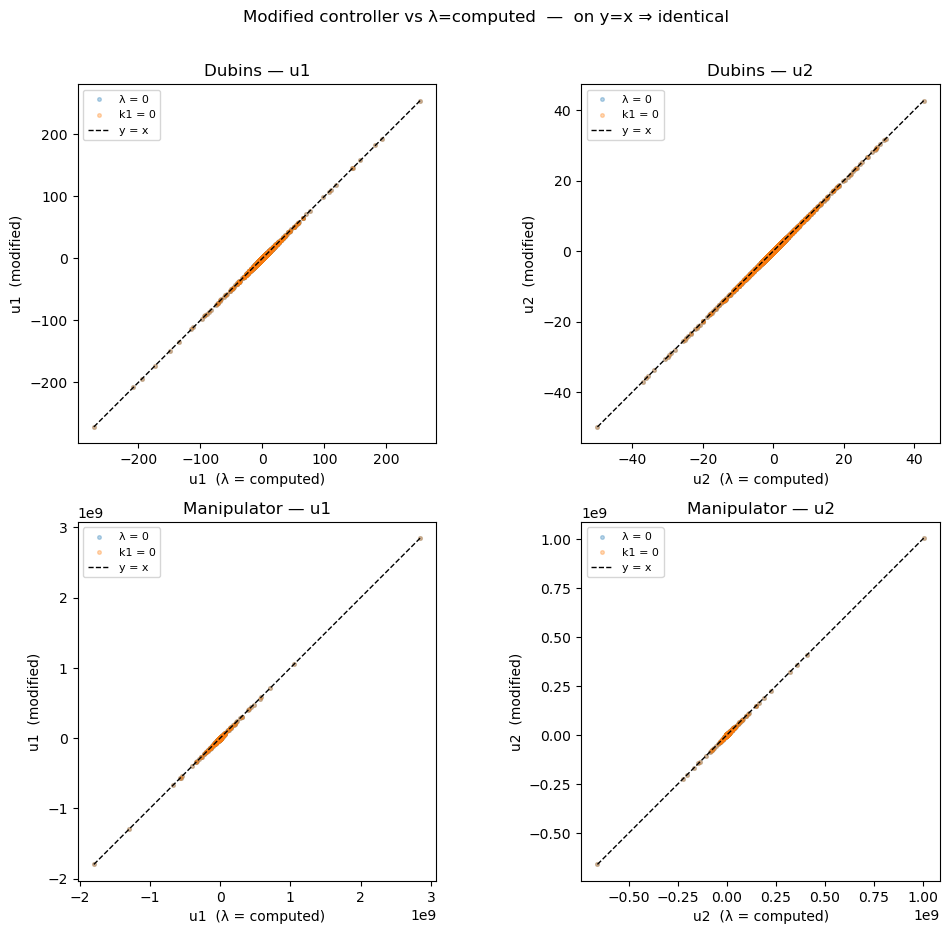

In [4]:
def subsample(n, k=4000, seed=0):
    if n <= k:
        return np.arange(n)
    return np.random.default_rng(seed).choice(n, k, replace=False)


ncols = max(len(d["dims"]) for d in DATASETS.values())
nrows = len(DATASETS)
fig, axes = plt.subplots(
    nrows, ncols, figsize=(5.2 * ncols, 4.6 * nrows), squeeze=False
)
for r, (name, d) in enumerate(DATASETS.items()):
    idx = subsample(len(d["df"]))
    for c, i in enumerate(d["dims"]):
        ax = axes[r][c]
        uf, uz, uk = d["full"][idx, c], d["zero"][idx, c], d["k0"][idx, c]
        ax.scatter(uf, uz, s=7, alpha=0.3, label="λ = 0")
        ax.scatter(uf, uk, s=7, alpha=0.3, label="k1 = 0")
        lo = min(uf.min(), uz.min(), uk.min())
        hi = max(uf.max(), uz.max(), uk.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
        ax.set_xlabel(f"u{i}  (λ = computed)")
        ax.set_ylabel(f"u{i}  (modified)")
        ax.set_title(f"{name} — u{i}")
        ax.legend(fontsize=8)
        ax.set_aspect("equal", "box")
    for c in range(len(d["dims"]), ncols):
        axes[r][c].axis("off")
fig.suptitle("Modified controller vs λ=computed  —  on y=x ⇒ identical", y=1.01)
fig.tight_layout()
plt.show()

## 2. How large is the change, relative to `|u|`?

Histogram of `log10(|Δu| / max|u|)` pooled over control dimensions. The dashed red
line marks the 1% level; everything sits many orders of magnitude below it.


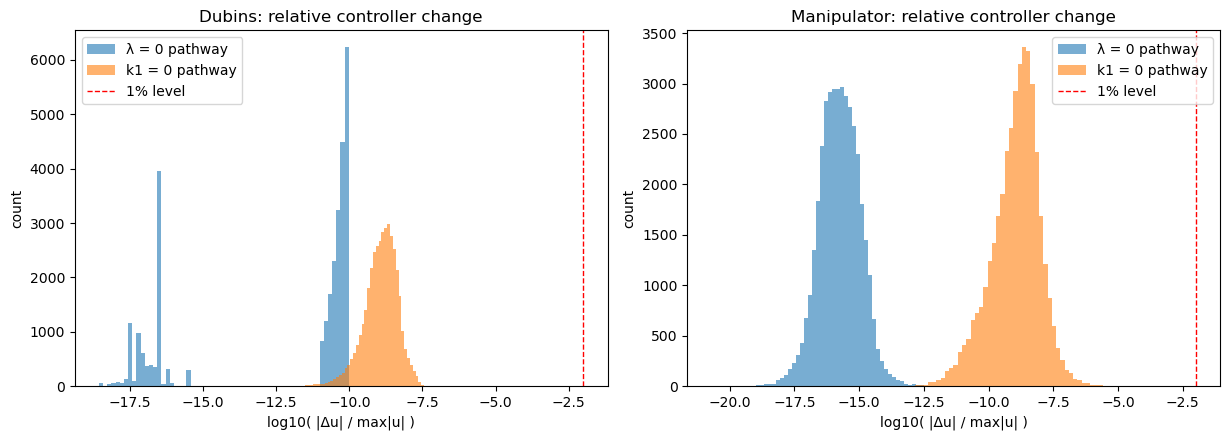

In [5]:
fig, axes = plt.subplots(
    1, len(DATASETS), figsize=(6.2 * len(DATASETS), 4.5), squeeze=False
)
for c, (name, d) in enumerate(DATASETS.items()):
    ax = axes[0][c]
    UF, UZ, UK = d["full"], d["zero"], d["k0"]
    scale = np.max(np.abs(UF), axis=0)  # per control dim
    rel_l = (np.abs(UF - UZ) / scale).ravel()
    rel_k = (np.abs(UF - UK) / scale).ravel()

    def logvals(a):
        a = a[np.isfinite(a) & (a > 0)]
        return np.log10(a)

    ax.hist(logvals(rel_l), bins=60, alpha=0.6, label="λ = 0 pathway")
    ax.hist(logvals(rel_k), bins=60, alpha=0.6, label="k1 = 0 pathway")
    ax.axvline(-2, color="r", ls="--", lw=1, label="1% level")
    ax.set_xlabel("log10( |Δu| / max|u| )")
    ax.set_ylabel("count")
    ax.set_title(f"{name}: relative controller change")
    ax.legend()
fig.tight_layout()
plt.show()

## 3. Change across **each** state dimension (full range, no slicing)

For every state coordinate, plotted over its full sampled range, the relative change
(worst control dim per sample) stays microscopic — so the conclusion is not an artifact
of fixing some dimensions. (log y-axis; zeros are dropped.)


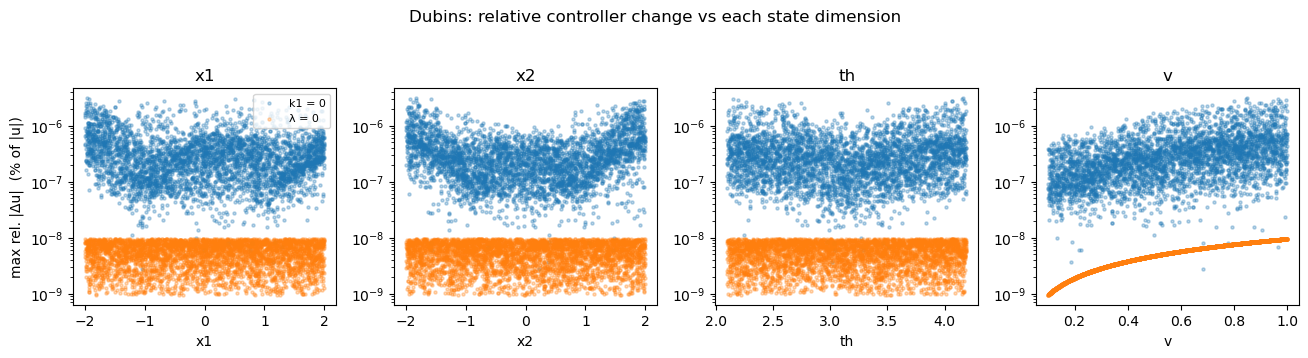

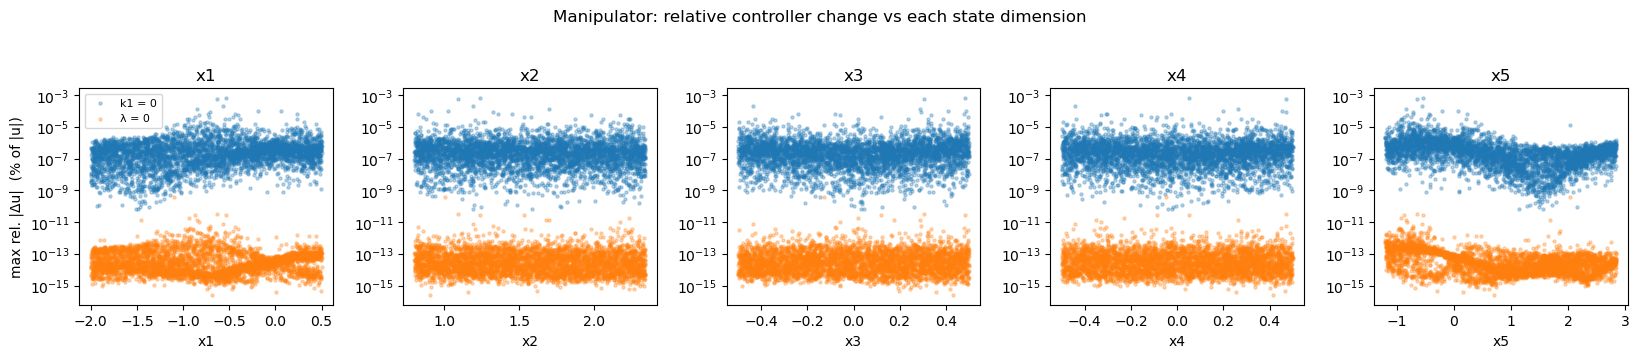

In [6]:
for name, d in DATASETS.items():
    UF, UZ, UK = d["full"], d["zero"], d["k0"]
    scale = np.max(np.abs(UF), axis=0)
    rel_k = np.max(np.abs(UF - UK) / scale, axis=1)  # worst control dim per sample
    rel_l = np.max(np.abs(UF - UZ) / scale, axis=1)
    sc, df = d["state_cols"], d["df"]
    idx = subsample(len(df))
    fig, axes = plt.subplots(1, len(sc), figsize=(3.3 * len(sc), 3.4), squeeze=False)
    for c, col in enumerate(sc):
        ax = axes[0][c]
        ax.scatter(
            df[col].values[idx], 100 * rel_k[idx], s=5, alpha=0.3, label="k1 = 0"
        )
        ax.scatter(df[col].values[idx], 100 * rel_l[idx], s=5, alpha=0.3, label="λ = 0")
        ax.set_yscale("log")
        ax.set_xlabel(col)
        if c == 0:
            ax.set_ylabel("max rel. |Δu|  (% of |u|)")
        ax.set_title(col)
    axes[0][0].legend(fontsize=8)
    fig.suptitle(f"{name}: relative controller change vs each state dimension", y=1.04)
    fig.tight_layout()
    plt.show()

## 4. What if `λ` were larger? (λ sweep)

Hypothesis: k1 is immaterial only because `λ ≈ 1e-8`; raising `λ` toward `μ`'s
magnitude should make the constructed k1 act. We hold the obtained k1 **fixed** and
sweep `λ` from `1e-8` to `1e3`, measuring k1's effect on `u` (= `max|u_full − u_k0| / max|u|`)
at each `λ`. Vertical lines mark `μ` and the solved `λ`; red lines are the 1/10/50% levels.

**Caveat (validity):** this is a _what-if_ sensitivity of the **same** k1 (synthesized at
the tiny solved `λ`), not a re-designed controller. A proper co-design would re-solve k1
for each `λ` — and since the vanilla solve makes k1 small precisely because `λ ≈ 0`, a
large-`λ` co-design could yield a larger k1 (k1's effect could then grow faster). This
sweep answers the literal question ("raise `λ`, does _this_ k1 act more?"); a co-design
re-solve is the stronger follow-up.


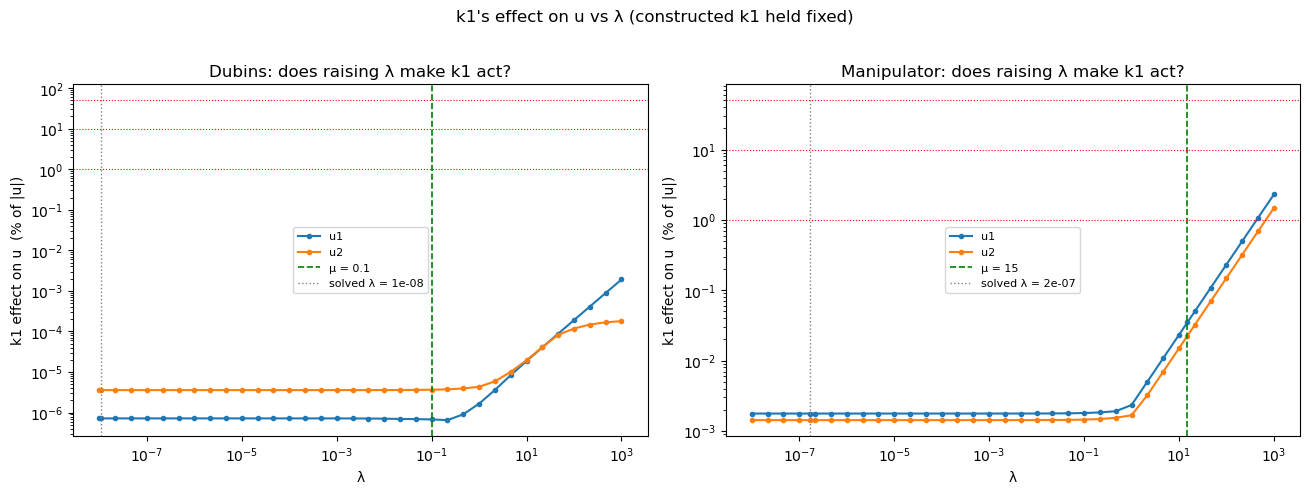

Dubins (μ=0.1):  k1 effect at λ=μ ≈ 3.66e-06%
    reaches  1% at λ ≥ never (≤1e3)
    reaches 10% at λ ≥ never (≤1e3)
    reaches 50% at λ ≥ never (≤1e3)
Manipulator (μ=15):  k1 effect at λ=μ ≈ 0.0349%
    reaches  1% at λ ≥ 464  (= 30.9·μ)
    reaches 10% at λ ≥ never (≤1e3)
    reaches 50% at λ ≥ never (≤1e3)


In [7]:
SWEEP_FILES = {
    "Dubins": "lambda_sweep_dubins_car.csv",
    "Manipulator": "lambda_sweep_manipulator.csv",
}
sweep = {n: pd.read_csv(os.path.join(DATA, f)) for n, f in SWEEP_FILES.items()}

fig, axes = plt.subplots(1, len(sweep), figsize=(6.6 * len(sweep), 4.8), squeeze=False)
for c, (name, df) in enumerate(sweep.items()):
    ax = axes[0][c]
    mu = df["mu_val"].iloc[0]
    lam0 = df["k1_lambda"].iloc[0]
    for i in sorted(df["dim"].unique()):
        sub = df[df["dim"] == i].sort_values("lambda")
        ax.loglog(
            sub["lambda"],
            sub["k1_effect_pct"].clip(lower=1e-12),
            marker="o",
            ms=3,
            label=f"u{int(i)}",
        )
    ax.axvline(mu, color="g", ls="--", lw=1.2, label=f"μ = {mu:g}")
    ax.axvline(lam0, color="gray", ls=":", lw=1.0, label=f"solved λ = {lam0:.1g}")
    for thr in (1, 10, 50):
        ax.axhline(thr, color="r", ls=":", lw=0.8)
    ax.set_xlabel("λ")
    ax.set_ylabel("k1 effect on u  (% of |u|)")
    ax.set_title(f"{name}: does raising λ make k1 act?")
    ax.legend(fontsize=8)
fig.suptitle("k1's effect on u vs λ (constructed k1 held fixed)", y=1.02)
fig.tight_layout()
plt.show()

# where does k1's effect cross 1% / 10% / 50% (worst control dim)?
for name, df in sweep.items():
    mu = df["mu_val"].iloc[0]
    worst = df.groupby("lambda")["k1_effect_pct"].max().sort_index()
    print(
        f"{name} (μ={mu:g}):  k1 effect at λ=μ ≈ "
        f"{worst.iloc[(worst.index - mu).to_series().abs().values.argmin()]:.3g}%"
    )
    for thr in (1, 10, 50):
        hit = worst[worst >= thr]
        print(
            f"    reaches {thr:>2}% at λ ≥ "
            + (
                f"{hit.index[0]:.3g}  (= {hit.index[0]/mu:.3g}·μ)"
                if len(hit)
                else "never (≤1e3)"
            )
        )

## 5. Proper co-design — raise the SOS floor `xi0` (lambda stays a decision variable)

Instead of holding the constructed k1 fixed, here we **re-solve** the vanilla k1 with the
floor `lambda >= xi0` raised toward `μ` (via `solve_vanilla_k1_controller_xi.m`). `lambda`
is _not_ fixed — it stays a decision variable, just floored higher — so each point is a
properly co-designed `(k1, lambda)` pair. We check feasibility, k1's effect on `u`, and the
control magnitude `max|u|`.


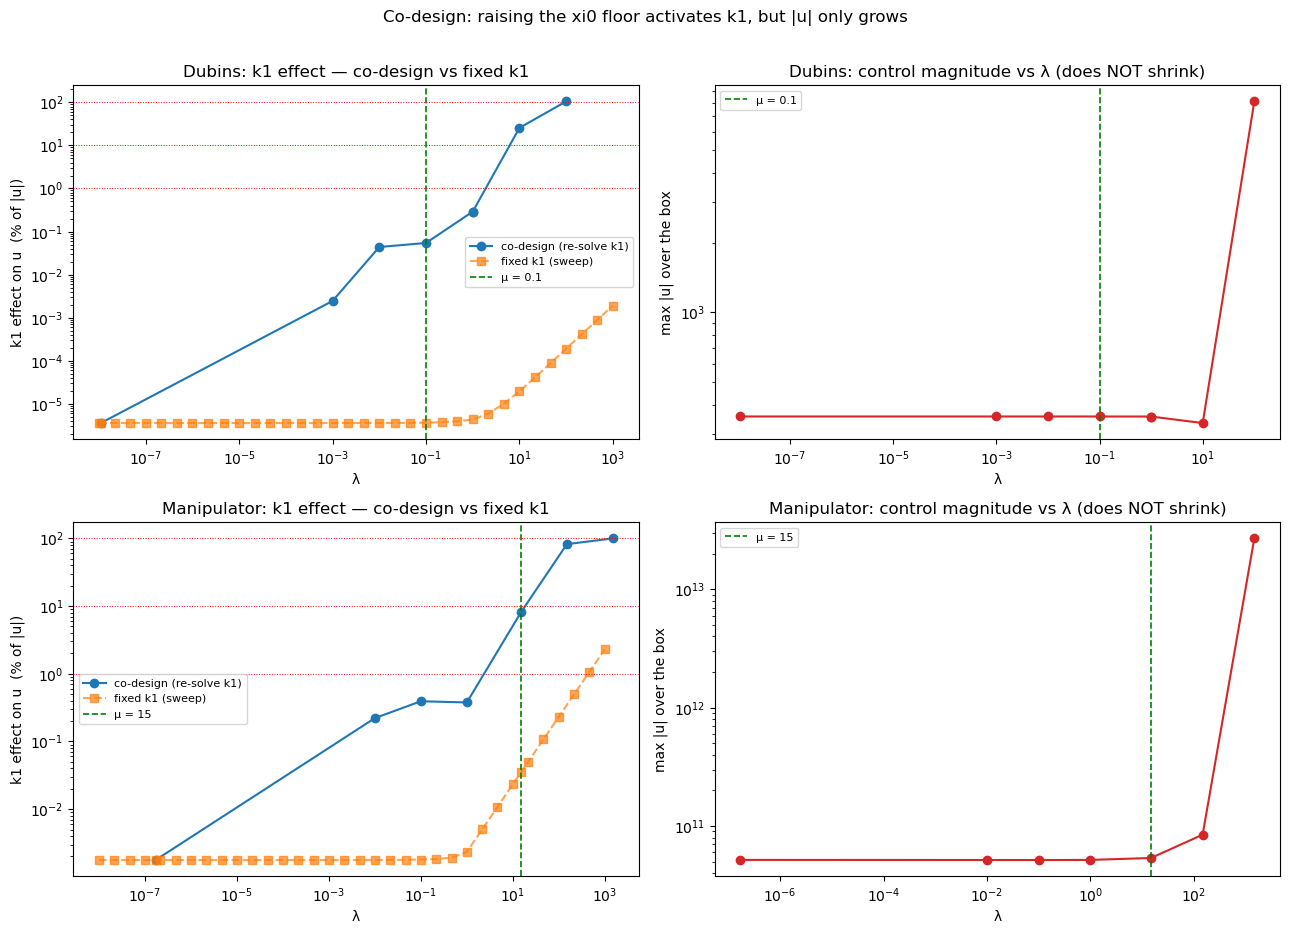

Dubins: all solves feasible = True;  at λ≈μ=0.1 -> k1 effect 0.0544%, max|u| = 356
Manipulator: all solves feasible = True;  at λ≈μ=15 -> k1 effect 8.08%, max|u| = 5.37e+10


In [8]:
CODESIGN_FILES = {
    "Dubins": "lambda_codesign_dubins_car.csv",
    "Manipulator": "lambda_codesign_manipulator.csv",
}
codes = {n: pd.read_csv(os.path.join(DATA, f)) for n, f in CODESIGN_FILES.items()}

fig, axes = plt.subplots(len(codes), 2, figsize=(13, 4.6 * len(codes)), squeeze=False)
for r, (name, cd) in enumerate(codes.items()):
    mu = cd["mu_val"].iloc[0]
    cd = cd.sort_values("solved_lambda")
    sw = sweep[name].groupby("lambda")["k1_effect_pct"].max().sort_index()
    # left: k1 effect, co-design vs fixed-k1 sweep
    ax = axes[r][0]
    ax.loglog(
        cd["solved_lambda"],
        cd["k1_effect_pct"].clip(lower=1e-12),
        "o-",
        label="co-design (re-solve k1)",
    )
    ax.loglog(
        sw.index, sw.clip(lower=1e-12), "s--", alpha=0.7, label="fixed k1 (sweep)"
    )
    ax.axvline(mu, color="g", ls="--", lw=1.2, label=f"μ = {mu:g}")
    for thr in (1, 10, 100):
        ax.axhline(thr, color="r", ls=":", lw=0.7)
    ax.set_xlabel("λ")
    ax.set_ylabel("k1 effect on u  (% of |u|)")
    ax.set_title(f"{name}: k1 effect — co-design vs fixed k1")
    ax.legend(fontsize=8)
    # right: control magnitude
    ax = axes[r][1]
    ax.loglog(cd["solved_lambda"], cd["max_u"], "o-", color="C3")
    ax.axvline(mu, color="g", ls="--", lw=1.2, label=f"μ = {mu:g}")
    ax.set_xlabel("λ")
    ax.set_ylabel("max |u| over the box")
    ax.set_title(f"{name}: control magnitude vs λ (does NOT shrink)")
    ax.legend(fontsize=8)
fig.suptitle(
    "Co-design: raising the xi0 floor activates k1, but |u| only grows", y=1.01
)
fig.tight_layout()
plt.show()

for name, cd in codes.items():
    mu = cd["mu_val"].iloc[0]
    at_mu = cd.iloc[(cd["solved_lambda"] - mu).abs().values.argmin()]
    print(
        f"{name}: all solves feasible = {int(cd['feasible'].min()) == 1};  "
        f"at λ≈μ={mu:g} -> k1 effect {at_mu['k1_effect_pct']:.3g}%, "
        f"max|u| = {at_mu['max_u']:.3g}"
    )

## 6. Can the SAMPLE constraints pull `u` into the bound? (co-design + slack SOP)

The decisive test: raise `xi0` (-> SOP k1 gets leverage), then run the whole-region
**slack** SOP and measure whether the _dense_ `|u|` actually shrinks toward the bound —
not just the slack at the samples. We also track the reach-avoid set size (validity).


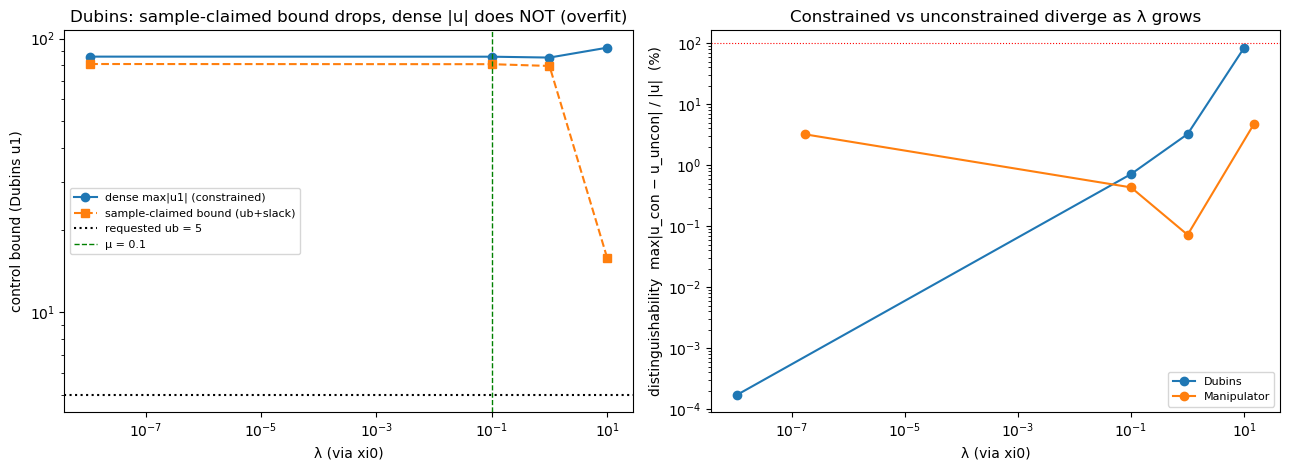

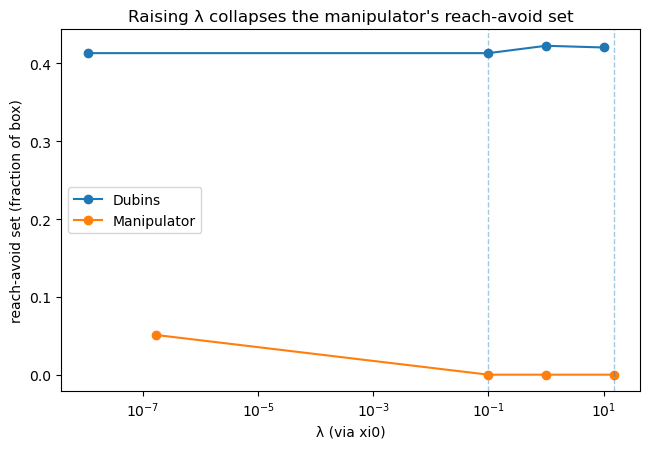

Dubins: reach-avoid set frac vs λ: 1.09e-08->0.413, 0.1->0.413, 1->0.423, 10->0.421
Manipulator: reach-avoid set frac vs λ: 1.7e-07->0.051, 0.1->0.000, 1->0.000, 15->0.000


In [9]:
COD_SOP = {
    "Dubins": "codesign_sop_dubins_car.csv",
    "Manipulator": "codesign_sop_manipulator.csv",
}
cs = {n: pd.read_csv(os.path.join(DATA, f)) for n, f in COD_SOP.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
# left: Dubins overfitting gap (u1)
d1 = cs["Dubins"][cs["Dubins"]["dim"] == 1].sort_values("lambda")
dense_abs = d1[["con_lo", "con_hi"]].abs().max(axis=1)
ax = axes[0]
ax.loglog(d1["lambda"], dense_abs, "o-", label="dense max|u1| (constrained)")
ax.loglog(
    d1["lambda"], d1["achievable"], "s--", label="sample-claimed bound (ub+slack)"
)
ax.axhline(
    d1["ub_req"].iloc[0],
    color="k",
    ls=":",
    label=f"requested ub = {d1['ub_req'].iloc[0]:g}",
)
ax.axvline(
    d1["mu_val"].iloc[0],
    color="g",
    ls="--",
    lw=1,
    label=f"μ = {d1['mu_val'].iloc[0]:g}",
)
ax.set_xlabel("λ (via xi0)")
ax.set_ylabel("control bound (Dubins u1)")
ax.set_title("Dubins: sample-claimed bound drops, dense |u| does NOT (overfit)")
ax.legend(fontsize=8)
# right: distinguishability vs lambda, both systems
ax = axes[1]
for n, df in cs.items():
    w = df.groupby("lambda")["dist_pct"].max().sort_index()
    ax.loglog(w.index, w.clip(lower=1e-6), "o-", label=n)
ax.axhline(100, color="r", ls=":", lw=0.8)
ax.set_xlabel("λ (via xi0)")
ax.set_ylabel("distinguishability  max|u_con − u_uncon| / |u|  (%)")
ax.set_title("Constrained vs unconstrained diverge as λ grows")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

# reach-avoid set fraction vs lambda
fig, ax = plt.subplots(figsize=(6.6, 4.6))
for n, df in cs.items():
    w = df.groupby("lambda")["raset_frac"].first().sort_index()
    ax.semilogx(w.index, w.values, "o-", label=n)
    ax.axvline(df["mu_val"].iloc[0], ls="--", lw=1, alpha=0.4)
ax.set_xlabel("λ (via xi0)")
ax.set_ylabel("reach-avoid set (fraction of box)")
ax.set_title("Raising λ collapses the manipulator's reach-avoid set")
ax.legend()
fig.tight_layout()
plt.show()

for n, df in cs.items():
    ra = df.groupby("lambda")["raset_frac"].first()
    print(
        f"{n}: reach-avoid set frac vs λ: "
        + ", ".join(f"{lam:.3g}->{v:.3f}" for lam, v in ra.items())
    )

## Conclusion

- `lambda` is pinned at its SOS floor `xi0 = 1e-8`, so the `0.5·λ·(Lf h − k1)` term is
  effectively zero: `u(λ=computed)` and `u(λ=0)` are bit-for-bit identical.
- Even removing `k1` entirely (value **and** Jacobian) leaves `u` essentially unchanged.
- **Raising `λ` to `μ`'s magnitude does _not_ help** (§4): with the constructed k1 fixed,
  at `λ=μ` k1's effect is still ~1e-6% (Dubins) / ~0.04% (manipulator). `μ` multiplies the
  _large_ safe-set gradient `Dψ`, while `λ` multiplies the _small_ `(Lf h − k1)`, so equal
  gains ≠ equal magnitudes.
- **Proper co-design** (§5, re-solve k1 with `xi0` raised) is _feasible_ (SOS solvable up to
  100·μ) and _does_ let k1 act more (manipulator reaches 8% at `λ=μ`, ~100% at `λ=100·μ`).
  **But it never reduces `|u|`** — `max|u|` stays flat (set by `μ·Dψ`) and then _blows up_
  (Dubins 356→8109, manipulator →2.7e13). k1 can be made to matter only by _adding_ control
  effort, never by bounding it.
- **Sample constraints + leverage (§6)**: raising `xi0` does make the constrained controller
  _distinct_ from the unconstrained one (Dubins: 84% at `λ=100·μ`) and drops the _sample-claimed_
  bound (80→16). But the **dense** `|u|` stays ~±92 — the SOP **overfits** the samples. And on the
  manipulator, raising `λ` even to 0.1 **collapses the reach-avoid set to empty** (`V(x)≥0` holds
  nowhere). So the samples cannot bound `u` densely while keeping a valid certificate.
- Therefore `u` is set by drift cancellation (`Lf^r h`) + `μ·∇ψ`; **`k1`/`λ` cannot bound `u`**,
  and the only effective lever on the control magnitude is `μ` (see `REVISION_NOTES.md` §4).
